# Data generation

In [3]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")

import numpy as np
from monaqa2.mcmc.model import IsingModel, RandomIsingModel

## Generation of SK instances

The instance is generated by first sampling all independent coefficients as $h_i \sim \mathcal{N}(0,1)$ and $J_{ij}\sim \mathcal{N}(0,1)$ for $i<j$. These coefficients are then normalized by the common factor $$\alpha=\sqrt{\frac{n}{\sum_i h_i^2+\sum_{i<j}J_{ij}^2}}.$$ 
The final coefficients are $\widetilde h_i=\alpha h_i$ and $\widetilde J_{ij}=\alpha J_{ij}$. The corresponding Ising energy is $E(s)=-\sum_{i<j}\widetilde J_{ij}s_i s_j-\sum_i \widetilde h_i s_i$, with $s_i\in\{\pm1\}$.

This differs from directly sampling independent coefficients as $h_i,J_{ij}\sim \mathcal{N}(0,\frac{2}{n+1})$. The similarity is that the normalized ensemble has the same marginal variance, namely 
$$\operatorname{Var}(\widetilde h_i)=\operatorname{Var}(\widetilde J_{ij})=\frac{n}{n+n(n-1)/2}=\frac{2}{n+1}.$$ 
Thus each coefficient still has the SK-type scaling $\widetilde h_i,\widetilde J_{ij}=O(n^{-1/2})$. The difference is that the normalized coefficients are not independent: their total squared norm is fixed exactly as $\sum_i \widetilde h_i^2+\sum_{i<j}\widetilde J_{ij}^2=n$. Therefore, this is a spherical ensemble rather than an independent Gaussian ensemble. For large $n$, individual coefficients look close to Gaussian, but finite-$n$ instances have no global norm fluctuations.

Instances can be created manually using IsingModel or generated randomly using the RandomIsingModel class:

In [2]:
from monaqa2.mcmc.model import IsingModel, RandomIsingModel

n = 3
random_model = RandomIsingModel(n=n, seed=1234)
print(f"Random model h=\n{random_model.h_rescaled}")
print(f"Random model J=\n{random_model.J_rescaled}")

# Static method from_coefficients expects a vector of length n + n(n-1)/2:
# first the n local fields h_i, then the upper-triangular couplings J_ij for i<j.
fixed_model = IsingModel.from_coefficients(
    n=n, 
    coefficients=np.hstack([random_model.h_rescaled, random_model.J_rescaled[np.triu_indices(n=n,k=1)]])
)
print(f"Fixed model h=\n{fixed_model.h_rescaled}")
print(f"Fixed model J=\n{fixed_model.J_rescaled}")

Random model h=
[-0.25689444 -0.46925507  0.09598513]
Random model J=
[[0.         0.03506258 0.40526672]
 [0.03506258 0.         1.59346204]
 [0.40526672 1.59346204 0.        ]]
Fixed model h=
[-0.25689444 -0.46925507  0.09598513]
Fixed model J=
[[0.         0.03506258 0.40526672]
 [0.03506258 0.         1.59346204]
 [0.40526672 1.59346204 0.        ]]


The instances used are the same one in the work [From quantum-enhanced to quantum-inspired Monte Carlo, Phys. Rev. A 111, 042615](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.111.042615) available here: [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc). These can be loaded using the following utilities.

In [2]:
from monaqa2.data import load_instances

In [6]:
n = 3 # between 3 and 10 included
idx = 0 # between 0 and 99 included
loaded_ising_model = load_instances(n, idx)
print(f"Loaded model h=\n{loaded_ising_model.h_rescaled}")
print(f"Loaded model J=\n{loaded_ising_model.J_rescaled}")

Loaded model h=
[-0.3958253  -1.23913116  0.7755628 ]
Loaded model J=
[[ 0.         -0.81979718  0.13006709]
 [-0.81979718  0.          0.13188543]
 [ 0.13006709  0.13188543  0.        ]]


## Upper bound on the 1-norm and operator norm


In [ ]:
import matplotlib.pyplot as plt

def one_norm_ub(m):
    return (np.abs(m.h_rescaled).sum() + np.abs(np.triu(m.J_rescaled, 1)).sum())

def two_norm_ub(m):
    return m.energies_rescaled.max() - m.energies_rescaled.min()


N_MODELS = 5
ns = np.arange(10, 5+1, 1)
U1 = np.array([[one_norm_ub(RandomIsingModel(n, seed=N_MODELS*n+i)) for i in range(N_MODELS)] for n in ns])
U2 = np.array([[two_norm_ub(RandomIsingModel(n, seed=N_MODELS*n+i)) for i in range(N_MODELS)] for n in ns])

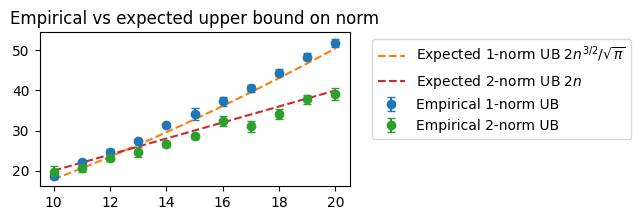

In [13]:
plt.figure(figsize=(4, 2))
plt.errorbar(ns, U1.mean(1), yerr=U1.std(1), fmt="o", capsize=3, label="Empirical 1-norm UB")
plt.plot(ns, 1/np.sqrt(np.pi)*ns**1.5, "--", label=r"Expected 1-norm UB $2n^{3/2}/\sqrt{\pi}$")
plt.errorbar(ns, U2.mean(1), yerr=U2.std(1), fmt="o", capsize=3, label="Empirical 2-norm UB")
plt.plot(ns, 2*ns, "--", label=r"Expected 2-norm UB $2n$")
plt.title("Empirical vs expected upper bound on norm")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Best hyperparameters for QEMC trial move

The dataset of instances from [From quantum-enhanced to quantum-inspired Monte Carlo, Phys. Rev. A 111, 042615](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.111.042615) already provide an extensive analysis regarding the hyperparameters $\gamma, t$ of the quantum enhances move working best for each $n$ and instance. These parameters can be loaded with the following:

In [13]:
from monaqa2.data import load_best_qemc_gamma_t, export_best_gamma_t_h5

load_best_qemc_gamma_t(n, idx)

(0.4631578947368421, 17.23404255319149)

Note that the method `export_best_gamma_t_h5` in the same module allows you to re-generate this file from the cloned repository of Petr's. For details regarding how these parameters are determine, refer to the original publication.  

## Reproduce spectral gaps calculation

We now reproduce the spectral-gap calculation for the transition matrices induced by the different proposal mechanisms. For each system size $n=3,\ldots,10$ and for each random Ising instance, we construct the Metropolis-type transition matrix associated with a proposal rule, an acceptance function, and an inverse temperature $\beta$.

The proposal rules considered are `uniform`, `local1`, `local2`, `local3`, `qemc`, and `layden`. The acceptance functions are parametrized by $a\in\{\infty,1,10\}$, where $a=\infty$ corresponds to the usual Metropolis acceptance rule and $a=1$ corresponds to Barker acceptance.

For each transition matrix $Q$, which is column-stochastic, we compute the symmetric discriminant matrix $X$ with entries $X_{ij}=\sqrt{Q_{ij}Q_{ji}}$. The reported spectral gap is the absolute spectral gap $1-\max_{\lambda\neq 1}|\lambda|$, where the eigenvalues are those of $X$. This is the relevant quantity for non-lazy chains, where negative eigenvalues may be present.

The results are stored in a `pandas` dataframe with columns `n`, `idx`, `proposal`, `a`, `beta`, and `delta`, where `delta` is the computed spectral gap. The table is saved after each completed pair `(n, idx)`, so the calculation can be resumed without recomputing entries that are already present.

In [9]:
from monaqa2.data import run_experiment_to_generate_spectral_gaps, load_spectral_gap

In [10]:
# Warning! Takes some time and skips results already computed
# (if file spectral_gap.pkl is present, it does nothing)
# run_experiment_to_generate_spectral_gaps()

In [11]:
load_spectral_gap("uniform", a=1).head()

,n,idx,beta,delta
0,3,0,0.01,0.492367
1,3,0,0.02,0.484742
2,3,0,0.03,0.477132
3,3,0,0.04,0.469544
4,3,0,0.05,0.461987


## Reproduce annealing calculation

We now reproduce the annealing schedules used to move from the infinite-temperature Gibbs distribution at $\beta_0=0$ to the target low-temperature distribution at $\beta_F=100$. 

For each Ising instance, the schedule is chosen so that consecutive coherent Gibbs states $\ket{\pi_\beta}=\sum_x\sqrt{\pi_\beta(x)}\ket{x}$ have overlap at least $\alpha=\sqrt{1/e}$.
In other words, for every consecutive pair $(\beta_k,\beta_{k+1})$, we require 
$$\langle \pi_{\beta_k}|\pi_{\beta_{k+1}}\rangle \ge \sqrt{1/e}.$$
This is sharper than imposing a fixed small increment in $\beta$, because it checks how much the actual Gibbs state changes between two temperatures. This overlap is exactly the Bhattacharyya coefficient between the two classical Gibbs distributions, namely $\sum_x \sqrt{\pi_{\beta_k}(x)\pi_{\beta_{k+1}}(x)}$.

The schedule is constructed greedily: starting from the current $\beta_k$, we choose the largest possible next value $\beta_{k+1}\le 100$ that still satisfies the overlap condition. Therefore, the number of intermediate temperatures is not fixed in advance and may vary from instance to instance.

**check here** The comparison with analytical bounds comes from the exact identity $\langle \pi_\beta|\pi_{\beta+\Delta}\rangle=Z(\beta+\Delta/2)/\sqrt{Z(\beta)Z(\beta+\Delta)}$. Since $\partial_\beta^2 \log Z(\beta)=\operatorname{Var}_{\pi_\beta}(E)$, the loss of overlap over the interval $[\beta,\beta+\Delta]$ can be bounded by the largest thermal energy variance on that interval. Writing 
$$V_{\max}=\sup_{\eta\in[\beta,\beta+\Delta]}\operatorname{Var}_{\pi_\eta}(E),$$ 
one obtains $-\log\langle \pi_\beta|\pi_{\beta+\Delta}\rangle\le V_{\max}\Delta^2/8$. Therefore, for the target overlap $\alpha=\sqrt{1/e}$, a sufficient condition is $\Delta\beta\le 2/\sqrt{V_{\max}}$.
For the normalized SK instances used here, this variance scale is easy to interpret at infinite temperature. At $\beta=0$, the Gibbs distribution is uniform and the spin monomials $s_i$ and $s_i s_j$ are orthogonal. Hence $\operatorname{Var}_{\pi_0}(E)=\sum_i h_i^2+\sum_{i<j}J_{ij}^2=n$ by construction. The variance bound therefore predicts an initial step of order $2/\sqrt n$ (for example you should see a first step for $n=10$ of $\beta_0 = 0 \to \beta_1 \approx 0.6$).

Alternatively, the [Wocjan bound](https://arxiv.org/abs/0804.4259) first shifts the energies to $E'(x)=E(x)-E_{\min}$, which does not change the Gibbs distribution. The corresponding diagonal Hamiltonian $H'=\sum_x E'(x)\ketbra{x}{x}$ has operator norm $\|H'\|=E_{\max}-E_{\min}=R$. Their bound gives $|\langle \pi_\beta|\pi_{\beta+\Delta}\rangle|^2\ge e^{-R\Delta}$, so to guarantee the same overlap $\alpha=\sqrt{1/e}$ it is enough to impose $\Delta\beta\le 1/R$.

| Criterion | Sufficient condition for $\alpha=\sqrt{1/e}$ | Quantity used |
|---|---:|---|
| Exact overlap search | directly check $\langle \pi_\beta|\pi_{\beta+\Delta}\rangle\ge\sqrt{1/e}$ | actual Gibbs distributions |
| Variance bound | $\Delta\beta\le 2/\sqrt{V_{\max}}$ | thermal energy fluctuations along the interval |
| Wocjan bound | $\Delta\beta\le 1/(E_{\max}-E_{\min})$ | worst-case energy range |

For the normalized SK instances used here, $\operatorname{Var}_{\pi_0}(E)=n$ exactly, so the variance bound predicts an initial step of order $1/\sqrt n$. This matches the observation that the first step for $n=10$ is around $0.6$. At lower temperature, however, $V_{\max}$ can become much smaller if the Gibbs distribution is already concentrated on low-energy states. In that regime, the variance bound and the exact-overlap criterion can allow large final jumps.

The schedules are stored in an HDF5 file as variable-length arrays, one for each pair $(n,\mathrm{idx})$. They can be generated and loaded as follows:

In [12]:
from monaqa2.data import run_experiment_to_generate_annealing_schedules, load_annealing_schedule
# run_experiment_to_generate_annealing_schedules() # regenerate schedules, fast!
load_annealing_schedule(10, 99)

array([  0.        ,   0.60718774,   1.7788677 , 100.        ])